<a href="https://colab.research.google.com/github/procoder369/ML-Projects/blob/main/naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import all libraries



In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [3]:
data = load_breast_cancer()
X = data.data          # 30 features: radius, texture, perimeter, area, smoothness, etc.
y = data.target        # 0 = malignant, 1 = benign

df = pd.DataFrame(X, columns=data.feature_names)
df['diagnosis'] = y

print(df.shape)                     # (569, 31)
print(df['diagnosis'].value_counts())  # check class balance
print(df.head(100))

(569, 31)
diagnosis
1    357
0    212
Name: count, dtype: int64
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.990         10.38          122.80     1001.0          0.11840   
1        20.570         17.77          132.90     1326.0          0.08474   
2        19.690         21.25          130.00     1203.0          0.10960   
3        11.420         20.38           77.58      386.1          0.14250   
4        20.290         14.34          135.10     1297.0          0.10030   
..          ...           ...             ...        ...              ...   
95       20.260         23.03          132.40     1264.0          0.09078   
96       12.180         17.84           77.79      451.1          0.10450   
97        9.787         19.94           62.11      294.5          0.10240   
98       11.600         12.84           74.34      412.6          0.08983   
99       14.420         19.77           94.48      642.5          0.09752   

    mean co

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
## train the model
model = GaussianNB()
model.fit(X_train_scaled, y_train)

GaussianNB()

In [7]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

print("Predicted labels:", y_pred[:10])
print("Probabilities:\n", y_proba[:5])

Predicted labels: [1 0 0 1 1 0 0 0 0 1]
Probabilities:
 [[1.34948255e-09 9.99999999e-01]
 [1.00000000e+00 4.42908666e-60]
 [1.00000000e+00 5.62404394e-12]
 [9.80109091e-12 1.00000000e+00]
 [8.10256814e-15 1.00000000e+00]]


Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



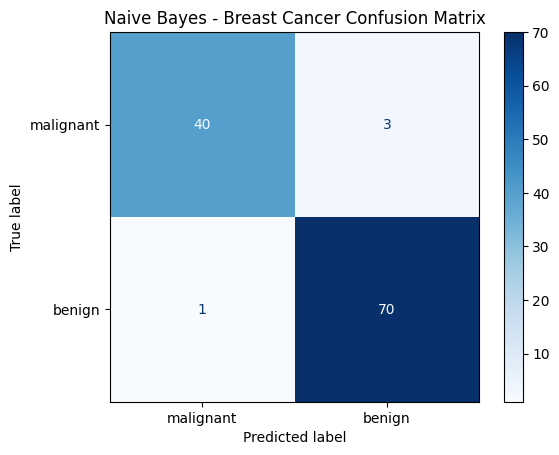

In [8]:
## Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title("Naive Bayes - Breast Cancer Confusion Matrix")
plt.show()

In [9]:
sample = X_test[0].reshape(1, -1)   # take one real sample as example
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)
probability = model.predict_proba(sample_scaled)

print("Predicted class:", data.target_names[prediction[0]])
print("Confidence:", probability[0])


Predicted class: benign
Confidence: [1.34948255e-09 9.99999999e-01]
